In [9]:
import numpy as np
import scipy.io
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [11]:
def load_mat_series(path):
    mat = scipy.io.loadmat(path)
    keys = [k for k in mat.keys() if not k.startswith("__")]
    return np.asarray(mat[keys[0]]).ravel().astype(float)

train = load_mat_series("Xtrain.mat")
test  = load_mat_series("Xtest.mat")

In [12]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train.reshape(-1,1)).ravel()
test_scaled  = scaler.transform(test.reshape(-1,1)).ravel()

In [13]:
def create_lag(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

In [14]:
def train_eval(window):
    X, y = create_lag(train_scaled, window)

    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror"
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_pred)
    mse = mean_squared_error(y_val, val_pred)

    return model, mae, mse

In [15]:
windows = [5, 10, 20, 30, 50]

results = []

for w in windows:
    model, mae, mse = train_eval(w)
    results.append((w, mae, mse))
    print(f"Window {w} -> MAE: {mae:.5f}, MSE: {mse:.5f}")

Window 5 -> MAE: 0.00871, MSE: 0.00016
Window 10 -> MAE: 0.00812, MSE: 0.00014
Window 20 -> MAE: 0.00788, MSE: 0.00014
Window 30 -> MAE: 0.00802, MSE: 0.00014
Window 50 -> MAE: 0.00853, MSE: 0.00017


In [16]:
best_window = min(results, key=lambda x: x[1])[0]
print("Best window:", best_window)

Best window: 20


In [17]:
X_full, y_full = create_lag(train_scaled, best_window)

best_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

best_model.fit(X_full, y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
input_seq = train_scaled[-best_window:].tolist()
preds = []

for _ in range(200):
    x_input = np.array(input_seq[-best_window:]).reshape(1,-1)
    next_val = best_model.predict(x_input)[0]
    
    preds.append(next_val)
    input_seq.append(next_val)

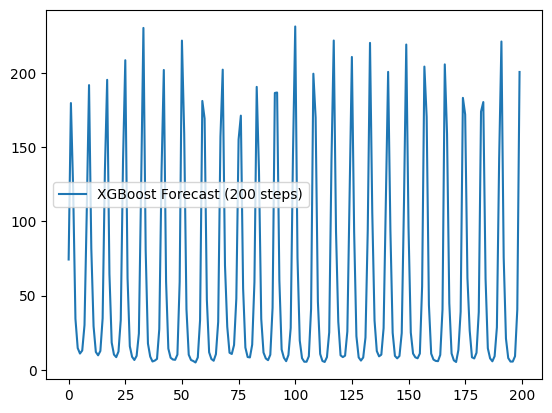

In [19]:
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1,1)).ravel()

plt.figure()
plt.plot(preds_inv, label="XGBoost Forecast (200 steps)")
plt.legend()
plt.show()

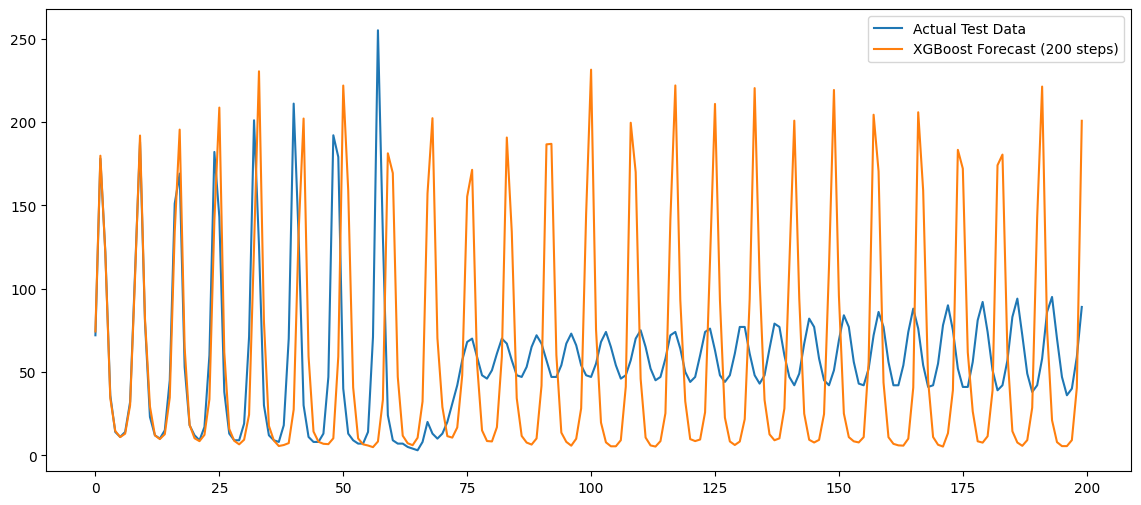

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(test, label="Actual Test Data")
plt.plot(preds_inv, label="XGBoost Forecast (200 steps)")
plt.legend()
plt.show()

In [26]:
mae = mean_absolute_error(test, preds_inv)
mse = mean_squared_error(test, preds_inv)
print(f"Final Test MAE: {mae:.5f}, MSE: {mse:.5f}")

Final Test MAE: 53.17726, MSE: 5320.94962


In [23]:
test_X, test_y = create_lag(test_scaled, best_window)

test_pred = best_model.predict(test_X)

mae = mean_absolute_error(test_y, test_pred)
mse = mean_squared_error(test_y, test_pred)

print("TEST MAE:", mae)
print("TEST MSE:", mse)

TEST MAE: 0.011314969904660247
TEST MSE: 0.0006019676930931716


In [24]:
test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1,1)).ravel()
test_y_inv = scaler.inverse_transform(test_y.reshape(-1,1)).ravel()

mae = mean_absolute_error(test_y_inv, test_pred_inv)
mse = mean_squared_error(test_y_inv, test_pred_inv)

print("TEST MAE:", mae)
print("TEST MSE:", mse)

TEST MAE: 2.862687259250217
TEST MSE: 38.53135260570657
